In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('heart_disease.csv')
data.shape

(4238, 16)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
data.head().T

,0,1,2,3,4
male,1.00,0.00,1.00,0.00,0.0
age,39.00,46.00,48.00,61.00,46.0
education,4.00,2.00,1.00,3.00,3.0
currentSmoker,0.00,0.00,1.00,1.00,1.0
cigsPerDay,0.00,0.00,20.00,30.00,23.0
BPMeds,0.00,0.00,0.00,0.00,0.0
prevalentStroke,0.00,0.00,0.00,0.00,0.0
prevalentHyp,0.00,0.00,0.00,1.00,0.0
diabetes,0.00,0.00,0.00,0.00,0.0
totChol,195.00,250.00,245.00,225.00,285.0


In [6]:
data.nunique()

male                  2
age                  39
education             4
currentSmoker         2
cigsPerDay           33
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
totChol             248
sysBP               234
diaBP               146
BMI                1363
heartRate            73
glucose             143
TenYearCHD            2
dtype: int64

In [7]:
data.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [9]:
# Filling missing values
data["BPMeds"] = data["BPMeds"].fillna(0)
data["education"] = data["education"].fillna(data["education"].mode()[0])
data["cigsPerDay"] = data["cigsPerDay"].fillna(data["cigsPerDay"].median())
data["totChol"] = data["totChol"].fillna(data["totChol"].median())
data["BMI"] = data["BMI"].fillna(data["BMI"].median())
data["heartRate"] = data["heartRate"].fillna(data["heartRate"].median())
data["glucose"] = data["glucose"].fillna(data["glucose"].median())

data.isna().sum().sum()

np.int64(0)

In [10]:
# Change some numerical columns to categorical
categorical_columns = [
    'male', 
    'education', 
    'currentSmoker', 
    'BPMeds', 
    'prevalentStroke', 
    'prevalentHyp', 
    'diabetes'
]

data[categorical_columns] = data[categorical_columns].astype('str')
data.dtypes

male                   str
age                  int64
education              str
currentSmoker          str
cigsPerDay         float64
BPMeds                 str
prevalentStroke        str
prevalentHyp           str
diabetes               str
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [12]:
data_numeric = data.copy()
data_numeric = data_numeric.drop(columns=categorical_columns + ['TenYearCHD'])

data_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.0000,70.0
cigsPerDay,4238.0,8.941482,11.902399,0.00,0.00,0.0,20.0000,70.0
totChol,4238.0,236.689476,44.327427,107.00,206.00,234.0,262.0000,696.0
sysBP,4238.0,132.352407,22.038097,83.50,117.00,128.0,144.0000,295.0
diaBP,4238.0,82.893464,11.910850,48.00,75.00,82.0,89.8750,142.5
BMI,4238.0,25.800205,4.071041,15.54,23.08,25.4,28.0375,56.8
heartRate,4238.0,75.878716,12.025185,44.00,68.00,75.0,83.0000,143.0
glucose,4238.0,81.603587,22.865246,40.00,72.00,78.0,85.0000,394.0


In [13]:
data_numeric.corr()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
age,1.000000,-0.191847,0.260105,0.394302,0.206104,0.135174,-0.012848,0.117788
cigsPerDay,-0.191847,1.000000,-0.026976,-0.088375,-0.056687,-0.092211,0.073853,-0.056863
totChol,0.260105,-0.026976,1.000000,0.207522,0.163888,0.114811,0.090537,0.045559
sysBP,0.394302,-0.088375,0.207522,1.000000,0.784002,0.325161,0.182143,0.135136
diaBP,0.206104,-0.056687,0.163888,0.784002,1.000000,0.376623,0.181257,0.059042
BMI,0.135174,-0.092211,0.114811,0.325161,0.376623,1.000000,0.067520,0.082219
heartRate,-0.012848,0.073853,0.090537,0.182143,0.181257,0.067520,1.000000,0.087315
glucose,0.117788,-0.056863,0.045559,0.135136,0.059042,0.082219,0.087315,1.000000


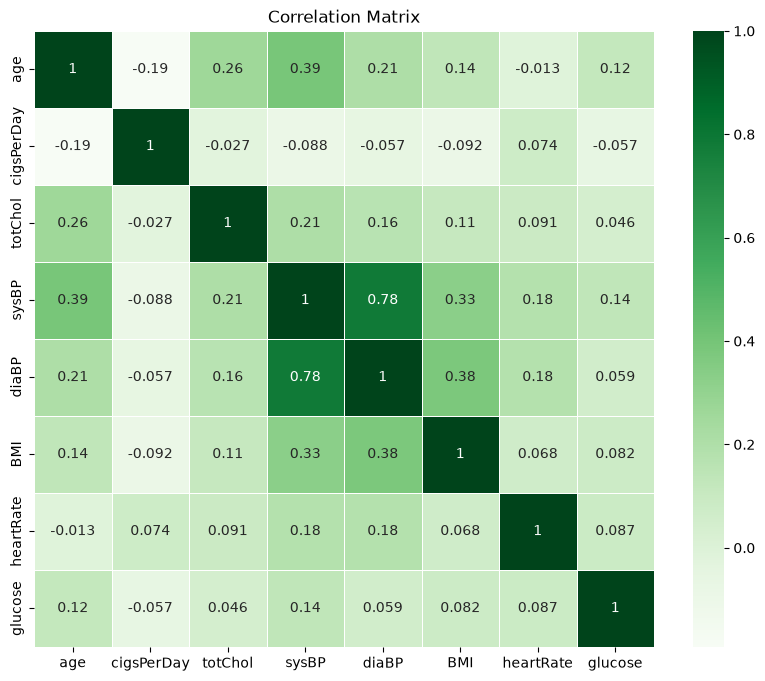

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(data_numeric.corr(), annot=True, cmap="Greens", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [20]:
data_numeric.corr().unstack().sort_values(ascending=False)

age         age           1.000000
cigsPerDay  cigsPerDay    1.000000
sysBP       sysBP         1.000000
totChol     totChol       1.000000
heartRate   heartRate     1.000000
                            ...   
sysBP       cigsPerDay   -0.088375
cigsPerDay  BMI          -0.092211
BMI         cigsPerDay   -0.092211
age         cigsPerDay   -0.191847
cigsPerDay  age          -0.191847
Length: 64, dtype: float64

In [21]:
data_numeric.corrwith(data['TenYearCHD']).sort_values(ascending=False)

age           0.225256
sysBP         0.216429
diaBP         0.145299
glucose       0.121277
totChol       0.081566
BMI           0.074217
cigsPerDay    0.058859
heartRate     0.022857
dtype: float64

#### Split the Data

In [22]:
SEED = 2

In [23]:
df_full_train, df_test = train_test_split(data, test_size=0.2, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=SEED)

assert len(df_full_train) == len(df_train) + len(df_val)

In [24]:
len(df_full_train), len(df_train), len(df_val), len(df_test)

(3390, 2542, 848, 848)

In [25]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.TenYearCHD.values
y_val = df_val.TenYearCHD.values
y_test = df_test.TenYearCHD.values

In [26]:
# Calculate mutual info:
def calculate_mutual_info(series):
    return mutual_info_score(series, df_train.TenYearCHD)

In [29]:
numerical_columns = data_numeric.columns.tolist()

In [31]:
df_mi = df_train[categorical_columns].apply(calculate_mutual_info)
df_mi = df_mi.sort_values(ascending=False)
df_mi

prevalentHyp       0.012699
male               0.004707
diabetes           0.003010
education          0.002185
prevalentStroke    0.002152
BPMeds             0.001680
currentSmoker      0.000658
dtype: float64

In [32]:
df_train = df_train.drop(columns=['TenYearCHD'])
df_val = df_val.drop(columns=['TenYearCHD'])
df_test = df_test.drop(columns=['TenYearCHD'])

assert "TenYearCHD" not in df_train.columns
assert "TenYearCHD" not in df_val.columns
assert "TenYearCHD" not in df_test.columns

In [33]:
dv = DictVectorizer(sparse=False)
train_dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

In [36]:
model = LogisticRegression(solver='lbfgs', random_state=SEED, max_iter=10000)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",2
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [37]:
val_dicts = df_val[categorical_columns + numerical_columns].to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = model.predict(X_val)

In [38]:
original_accuracy = accuracy_score(y_val, y_pred)
original_accuracy

0.8455188679245284

#### Regularization

In [39]:
scores = {}
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='lbfgs', random_state=SEED, C=C, max_iter=10000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    
    scores[C] = round(score, 3)
    print(f"C={C}, Accuracy={score}")

C=0.01, Accuracy=0.8514150943396226
C=0.1, Accuracy=0.8525943396226415
C=1, Accuracy=0.8455188679245284
C=10, Accuracy=0.8455188679245284
C=100, Accuracy=0.8455188679245284


In [40]:
print("Best C:", max(scores, key=scores.get), "with Accuracy:", max(scores.values()))

Best C: 0.1 with Accuracy: 0.853


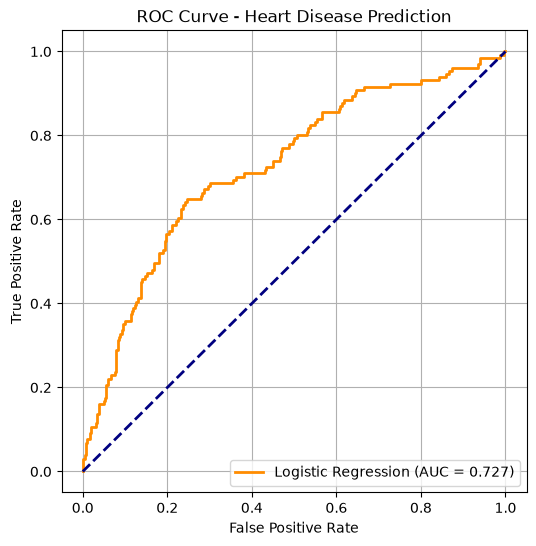

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the probabilities (the probability of being class 1)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
auc_score = roc_auc_score(y_val, y_pred_proba)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Heart Disease Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()